In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
import sys
sys.path.append('/content/drive/MyDrive')
%cd /content/drive/MyDrive/StereoSpikeA

Mounted at /content/drive/
/content/drive/MyDrive/StereoSpikeA


In [ ]:
%cd /content/drive/MyDrive/StereoSpikeA  # PARA SERGI
# J-MOD2: Joint Monocular Obstacle Detection and Depth Estimation
#!git clone https://github.com/isarlab-department-engineering/J-MOD2.git
# Learning Monocular Dense Depth from Events
#!git clone https://github.com/uzh-rpg/rpg_e2depth.git
# for ROS node converter of events
#!git clone https://github.com/fbarranco/dvs_clustering_tracking.git

[Errno 2] No such file or directory: '/content/drive/MyDrive/StereoSpikeA # PARA SERGI'
/content/drive/MyDrive/StereoSpikeA


In [ ]:
!pip install -r requirements.txt
#!pip install cupy

In [ ]:
!python test.py


In [ ]:
!python train.py

TRAIN

## PREDICCIÓN ESTEREO

Librerias

In [ ]:
import time
import random
from tqdm import tqdm
#import numpy as np
import cupy as np
#import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter

from spikingjelly.clock_driven import functional
from spikingjelly.clock_driven import surrogate

#from datasets.MVSEC import load_MVSEC
from datasets.MVSEC.mvsec_dataset import split_MVSEC #, EVIMODatasetBase
from datasets.data_augmentation import ToTensor,ToTensor_mono, \
    RandomHorizontalFlip, RandomVerticalFlip, RandomTimeMirror, \
    RandomEventDrop

#from network.SNN_models import StereoSpike, fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike
from network.SNN_models import StereoSpike, \
    fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike,\
    fromZero_feedforward_multiscale_tempo_Matt_noskip_Motion5

from network.metrics import MeanDepthError, log_to_lin_depths, disparity_to_depth
from network.loss2 import Total_Loss, DiceLoss

#from viz import show_learning

##############################
# DEVICE AND REPRODUCIBILITY #
##############################

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

set_random_seed(2021)

######################
# GENERAL PARAMETERS #
######################

nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)
batchsize = 1		
learned_metric = 'LIN' # learn metric depth ('LIN'), normalized log depth ('LOG') or disparity ('DISP')
learning_rate = 0.0002
weight_decay = 0.0
n_epochs = 70
batch_size=1

########
# DATA #
########

# random transformations for data augmentation
tsfm = transforms.Compose([
    ToTensor_mono(),
    #RandomHorizontalFlip(p=0.5),
    #RandomVerticalFlip(p=0.5),
    #RandomTimeMirror(p=0.5),
    #RandomEventDrop(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs2.txt", "w+")
tb_writer = SummaryWriter('./results/checkpoints/')

ModuleNotFoundError: ignored

Base de datos GENERALIZADO

In [ ]:

dataset_dir = './datasets/MVSEC/data/'
#scenario_dir = 'outdoor_day'
#scenario_dir = 'indoor_flying'
scenario_dir = 'outdoor_night'
#outdoor_nigh = 840000000

train_set, val_set, test_set = split_MVSEC(dataset_dir, 
                        scenario=scenario_dir, min_lim=0, max_lim=0.1, #limitates the size of the dataset in percentage, #if max_min<min_lim then use real length as limit
                        batch_size=batch_size,
                        num_frames_per_depth_map=nfpdm, #1
                        warmup_chunks=0, 
                        train_chunks=1,
                        transform=tsfm, 
                        normalize=False, 
                        learn_on='LIN',
                        load_test_only=False)

# test_set = split_MVSEC(dataset_dir, 
#                         scenario=scenario_dir, 
#                         batch_size=batch_size,
#                         num_frames_per_depth_map=nfpdm, 
#                         warmup_chunks=0, 
#                         train_chunks=1,
#                         transform=tsfm, 
#                         normalize=False, 
#                         learn_on='LIN',
#                         load_test_only=True)

train_data_loader = torch.utils.data.DataLoader(dataset=train_set,
                                                batch_size=batchsize,
                                                shuffle=True,
                                                drop_last=True,
                                                pin_memory=True)

val_data_loader = torch.utils.data.DataLoader(dataset=val_set,
                                              batch_size=1,
                                              shuffle=False,
                                              drop_last=True,
                                              pin_memory=True)

test_data_loader = torch.utils.data.DataLoader(dataset=test_set,
                                               batch_size=1,
                                               shuffle=False,
                                               drop_last=True,
                                               pin_memory=True)





/content/drive/MyDrive/StereoSpikeA/network/SNN_models.py
/content/drive/MyDrive/StereoSpikeA/test.py
/content/drive/MyDrive/StereoSpikeA/train.py
/content/drive/MyDrive/StereoSpikeA/requirements.txt
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/mvsec_dataset.py
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/utils.py
/content/drive/MyDrive/StereoSpikeA/viz.py
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/utils.py
/content/drive/MyDrive/rpg_e2depth


/content/drive/MyDrive/StereoSpikeA/train_evimo.py
/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/base.py

/content/drive/MyDrive/SpikeMS/train.py
/content/drive/MyDrive/SpikeMS/runner2.py

#Train loop

In [ ]:
###########
# NETWORK #
###########

# net = StereoSpike(surrogate_function=surrogate.ATan(), detach_reset=True, v_threshold=1.0, v_reset=0.).to(device)
# net = StereoSpike_equivalentANN(activation_function=nn.Sigmoid()).to(device)
# net = fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike(tau=3., v_threshold=1.0, v_reset=0.0, use_plif=True, multiply_factor=10.).to(device)
net = fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike(tau=3., 
                                                                       v_threshold=1.0, 
                                                                       v_reset=0.0, 
                                                                       use_plif=True, 
                                                                       multiply_factor=10.).to(device)
#net = fromZero_feedforward_multiscale_tempo_Matt_noskip_Motion5(tau=3., v_threshold=1.0, v_reset=0.0, use_plif=True, multiply_factor=10.).to(device)
################
# OPTIMIZATION #
################

optimizer   = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler   = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[8, 42, 60], gamma=0.5)
loss_module = Total_Loss(alpha=0.5, scale_weights=(1., 1., 1., 1.), penalize_spikes=False)


from viz import show_learning
import matplotlib.pyplot as plt
#from datasets.MVSEC import load_MVSEC

###########################
# VISUALIZATION FUNCTIONS #
###########################

plt.ion()
fig = plt.figure()

############
# TRAINING #
############

for epoch in range(n_epochs):

    running_train_loss = 0
    running_train_MDE = 0
    running_test_loss = 0
    running_test_MDE = 0
    i=0
    show = False            # display network's predictions during training / validation
    net.train()
    start_time = time.time()
    for init_pots, train_chunks_left, label in tqdm(train_data_loader, desc='training'):

        # Pass tensors on the GPU / CPU
        init_pots = init_pots.to(device)
        #print("\n tensor1: (BS,Ni,nfpdm,C,H,W)=",train_chunks_left.shape)  

        train_chunks_left = train_chunks_left.to(device, dtype=torch.float)
        label = label.to(device)

        # reshape the inputs (B, num_chunks, nfpdm, 2, 260, 346) --> (B, num_chunks*nfpdm, 2, 260, 346)
        train_chunks_left = train_chunks_left.view(batchsize, N_inference * nfpdm, 2, 260, 346)
       
        #print("\n tensor2: (BS,Ni*nfpdm,C,H,W)=",train_chunks_left.shape)    
        # concatenate subsequent frames channel-wise: (B, num_frames, 2, 260, 346) --> (B, 1, num_frames*2, 260, 346)
        # where num_frames = num_chunks * nfpdm
        # Used to give some sort of temporal information to the stateless model via the input
        # /!\ number of filters in the first convolution should be changes accordingly /!\
       
        train_chunks_left = train_chunks_left.view(batchsize, 1, N_inference * nfpdm * 2, 260, 346)
        #train_chunks_left = train_chunks_left.permute(1,0,2,3,4)

        #print("\n tensor3: (Ni*nfpdm,BS,C,H,W)=",train_chunks_left.shape)    
    

        # initialize all neuron potentials
        functional.reset_net(net)

        # let intermediate neurons "warm up" and reach a steady state before "real" training
        # Useful for stateful models, but not used, as StereoSpike is stateless
        '''
        with torch.no_grad():
            net(warmup_chunks_left, warmup_chunks_right)
        '''

        # forward pass a long sequence of chunks
        #pred, spks = net(train_chunks)  
        # for monocular models: 
        #train_chunks_left = train_chunks_left[:, 0, :, :, :]
        #print("\n test_chunks_left.size: ",train_chunks_left.size())

        pred, spks= net(train_chunks_left) # 4,5, = net(5)
        #pred[0] = pred[0][0,:, :, :, :]
        
        #print("\n spks.size: ",spks.size())
        #print(" ...vacío... ") if not torch.any(train_chunks_left) else: print(" ...lleno... ") ###########################
        # confront prediction and groundtruth
        if show:
            show_learning(fig, False, train_chunks_left, pred[0], label, 'train',i) # fig object, save in file, input, prediction, gt
            i +=1
        
        #if not torch.any(train_chunks_left[0, :, :, :]): print(" ...vacío... ")           
        #else: print("...lleno...") ###########################
        
        # if not np.all(rect_Levents): print(" ...vacío... ") 
        # else: print("...lleno...") ###########################
        
        #print("pred: ", torch.tensor(pred[0]).shape)
        #print("train_chunks_left: ", train_chunks_left.shape)
        #print("spks: ", torch.tensor(spks[0]).shape)        
        #print("labels: ", torch.tensor(label).shape) 
        # calculate loss and update weights with BPTT
        
        #print("\n pred.size: ",pred[0].size())        
        #print("\n label.size: ",label.size())  
        loss = loss_module(pred, label,spks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        net.detach()

        # convert prediction and groundtruth back to linear (metric) depth, for Mean Depth Error (MDE) calculation
        # only consider full scale prediction for evaluation
        if learned_metric == 'LIN':
            lin_pred = pred[0]
            lin_label = label
        elif learned_metric == 'LOG':
            lin_pred = log_to_lin_depths(pred[0])
            lin_label = log_to_lin_depths(label)
        elif learned_metric == 'DISP':
            lin_pred = disparity_to_depth(pred[0])
            lin_label = disparity_to_depth(label)

        # calculate MDE
        MDE = MeanDepthError(lin_pred, lin_label)

        # save metrics
        running_train_loss += loss.item() * train_chunks_left.size(0)
        running_train_MDE += MDE

    # process saved metrics
    epoch_train_loss = running_train_loss / len(train_data_loader)
    epoch_train_MDE = running_train_MDE / len(train_data_loader)
    epoch_train_time = time.time() - start_time
    train_epoch_summary = "Epoch: {}, Training Loss: {}, Training Mean Depth Error (m): {}, Time: {}\n".format(epoch, epoch_train_loss, epoch_train_MDE, epoch_train_time)

    tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
    tb_writer.add_scalar('train_MDE', epoch_train_MDE, epoch)

    net.eval()
    show = True
    i=0
    with torch.no_grad():
        start_time = time.time()
        for init_pots, test_chunks_left, label in tqdm(val_data_loader, desc='validating'):

            # Pass tensors on the GPU / CPU
            init_pots = init_pots.to(device)
            test_chunks_left = test_chunks_left.to(device, dtype=torch.float)

            #test_chunks_right = test_chunks_right.to(device, dtype=torch.float)
            label = label.to(device)

            # reshape the inputs (B, num_chunks, nfpdm, 2, 260, 346) --> (B, num_chunks*nfpdm, 2, 260, 346)
       
            test_chunks_left = test_chunks_left.view(1, N_inference * nfpdm, 2, 260, 346)
   
            # concatenate train chunks channelwise: (B, num_frames, 2, 260, 346) --> (B, 1, num_frames*2, 260, 346)
            # where num_frames = num_chunks * nfpdm
            # (for "tempo" feedforward ANN models, comment for other models)
        
            test_chunks_left = test_chunks_left.view(1, 1, N_inference * nfpdm * 2, 260, 346)
            #test_chunks_left = test_chunks_left.permute(1,0,2,3,4)

            # concatenate left and right inputs channel-wise
            # (for binocular model)
            #warmup_chunks = torch.cat((warmup_chunks_left, warmup_chunks_right), dim=2)
            #test_chunks = torch.cat((test_chunks_left, test_chunks_right), dim=2)

            functional.reset_net(net)
            '''
            net(warmup_chunks_left, warmup_chunks_right)
            '''
            #pred, spks = net(test_chunks)  
            # for monocular models: 
            
            pred,spks = net(test_chunks_left)
            #pred[0] = pred[0][0,:, :, :, :]
            if show:
                show_learning(fig, False,test_chunks_left, pred[0], label, 'eval',i)
                i +=1

            loss = loss_module(pred, label,spks)
            net.detach()

            if learned_metric == 'LIN':
                lin_pred = pred[0]
            elif learned_metric == 'LOG':
                lin_pred = log_to_lin_depths(pred[0])
            elif learned_metric == 'DISP':
                lin_pred = disparity_to_depth(pred[0])

            MDE = MeanDepthError(lin_pred, label)

            running_test_loss += loss.item() / test_chunks_left.size(0)
            running_test_MDE += MDE

    epoch_test_loss = running_test_loss / len(val_data_loader)
    epoch_test_MDE = running_test_MDE / len(val_data_loader)
    epoch_test_time = time.time() - start_time
    test_epoch_summary = "Epoch: {}, Test Loss: {}, Test Mean Depth Error (m): {}, Time: {}\n".format(epoch,epoch_test_loss, epoch_test_MDE,epoch_test_time)
    print(train_epoch_summary + test_epoch_summary)
    logfile.write(train_epoch_summary + test_epoch_summary)

    tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
    tb_writer.add_scalar('test_MDE', epoch_test_MDE, epoch)

    # save model if better results
    if epoch_test_MDE < net.get_max_accuracy():
        print("Best performances so far: saving model...\n")
        logfile.write("Best performances so far: saving model...\n")
        torch.save(net.state_dict(), "./results/checkpoints/stereospike_mono.pth")
        net.update_max_accuracy(epoch_test_MDE)

    net.increment_epoch()

    scheduler.step()

print("training finished !")


# Test

In [ ]:
show = True
from viz import show_learning
import matplotlib.pyplot as plt
#from datasets.MVSEC import load_MVSEC

###########################
# VISUALIZATION FUNCTIONS #
###########################

plt.ion()
fig = plt.figure()

###########
# NETWORK #
###########

#net = StereoSpike(surrogate_function=surrogate.ATan(), detach_reset=True, v_threshold=1.0, v_reset=0.).to(device)
#net = StereoSpike_equivalentANN(activation_function=nn.Sigmoid()).to(device)
#net = fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike(tau=3., v_threshold=1.0, v_reset=0.0, use_plif=True, multiply_factor=10.).to(device)
net = fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike(tau=3., v_threshold=1.0, v_reset=0.0, use_plif=True, multiply_factor=10.).to(device)

net.load_state_dict(torch.load('./results/checkpoints/stereospike_mono.pth'))
loss_module = Total_Loss(alpha=0.5, scale_weights=(1., 1., 1., 1.), penalize_spikes=False)

############
# TESTING #
############
with torch.no_grad():

    start_time = time.time()
    running_test_loss = 0
    running_test_MDE = 0
    i = 0

    for init_pots, test_chunks_left, label in tqdm(test_data_loader, desc='testing'):
            #print("test_chunks_left.size 1 \n")
            #print(test_chunks_left.size())
            # Pass tensors on the GPU / CPU
        init_pots = init_pots.to(device)
            #warmup_chunks_left = warmup_chunks_left.to(device, dtype=torch.float)
            #warmup_chunks_right = warmup_chunks_right.to(device, dtype=torch.float)
        test_chunks_left = test_chunks_left.to(device, dtype=torch.float)
            #test_chunks_right = test_chunks_right.to(device, dtype=torch.float)
            #print("test_chunks_left.size 2 \n")
            #print(test_chunks_left.size())
        label = label.to(device)

            # reshape the inputs (B, num_chunks, nfpdm, 2, 260, 346) --> (B, num_chunks*nfpdm, 2, 260, 346)
            #warmup_chunks_left = warmup_chunks_left.view(1, N_warmup * nfpdm, 2, 260, 346)
            #warmup_chunks_right = warmup_chunks_right.view(1, N_warmup * nfpdm, 2, 260, 346)
        test_chunks_left = test_chunks_left.view(1, N_inference * nfpdm, 2, 260, 346)
            #test_chunks_right = test_chunks_right.view(1, N_inference * nfpdm, 2, 260, 346)
            #print("test_chunks_left.size 3 \n")
            #print(test_chunks_left.size())
            # concatenate subsequent frames channel-wise: (B, num_frames, 2, 260, 346) --> (B, 1, num_frames*2, 260, 346)
            # where num_frames = num_chunks * nfpdm
            # Used to give some sort of temporal information to the stateless model via the input
            # /!\ number of filters in the first convolution should be changes accordingly /!\
            #warmup_chunks_left = warmup_chunks_left.view(1, 1, N_warmup * nfpdm * 2, 260, 346)
            #warmup_chunks_right = warmup_chunks_right.view(1, 1, N_warmup * nfpdm * 2, 260, 346)
        test_chunks_left = test_chunks_left.view(1, 1, N_inference * nfpdm * 2, 260, 346)
            #test_chunks_right = test_chunks_right.view(1, 1, N_inference * nfpdm * 2, 260, 346)

            # concatenate left and right inputs channel-wise
            # (for binocular model, ignore for monocular model)
            #warmup_chunks = torch.cat((warmup_chunks_left, warmup_chunks_right), dim=2)
            #test_chunks = torch.cat((test_chunks_left, test_chunks_right), dim=2)

            # initialize all neuron potentials
        functional.reset_net(net)

            # let intermediate neurons "warm up" and reach a steady state before "real" training
            # Useful for stateful models, but not used, as StereoSpike is stateless
        '''
        with torch.no_grad():
            net(warmup_chunks_left, warmup_chunks_right)
        '''

        # forward pass a long sequence of chunks
        #pred, spks = net(test_chunks)  
        # for monocular models: 
        #print("test_chunks_left.size 4\n")
        print(test_chunks_left.size())
        #calc_start_time = time.time()    
        pred, spks = net(test_chunks_left)
        #calc_time = time.time() - calc_start_time
        #print("time to predict ")
        #print(calc_time)
        # confront prediction and groundtruth
        if show:
            show_learning(fig, False,test_chunks_left, pred[0], label, 'eval',i)

        # calculate loss
        loss = loss_module(pred, label, spks)

        # only convert prediction back to linear (metric) depth, for Mean Depth Error (MDE) calculation
        # only consider full scale prediction for evaluation
        if learned_metric == 'LIN':
            lin_pred = pred[0]
        elif learned_metric == 'LOG':
            lin_pred = log_to_lin_depths(pred[0])
        elif learned_metric == 'DISP':
            lin_pred = disparity_to_depth(pred[0])

        # calculate MDE
        MDE = MeanDepthError(lin_pred, label)

        # save metrics
        running_test_loss += loss.item() / test_chunks_left.size(0)
        running_test_MDE += MDE

epoch_test_loss = running_test_loss / len(test_data_loader)
epoch_test_MDE = running_test_MDE / len(test_data_loader)
epoch_test_time = time.time() - start_time

# show results
test_epoch_summary = "\n Test Loss: {}, Test Mean Depth Error (m): {}, Time: {}\n".format(
    epoch_test_loss,
    epoch_test_MDE,  
    epoch_test_time )    

## Librerias

In [ ]:
import time
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import torchvision.transforms.functional as F

from spikingjelly.clock_driven import functional
from spikingjelly.clock_driven import surrogate

from network.metrics import MeanDepthError, log_to_lin_depths, disparity_to_depth
from network.loss import Total_Loss_Motion_3

from datasets.MVSEC import load_MVSEC
from datasets.data_augmentation import ToTensor, ToTensor_mono, RandomHorizontalFlip, RandomVerticalFlip, RandomTimeMirror, \
    RandomEventDrop

#from network.SNN_models import StereoSpike, fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike
from network.SNN_models import StereoSpike, fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike
from network.ANN_models import StereoSpike_equivalentANN

from torchsummary import summary

from viz import show_learning, make_vid_from_pngs

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

#from viz import show_learning



# Modelo de red

In [ ]:
######################
# GENERAL PARAMETERS #
######################

nfpdm = 10            # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)
batchsize = 1		
learned_metric = 'LIN' # learn metric depth ('LIN'), normalized log depth ('LOG') or disparity ('DISP')
learning_rate = 0.0002
weight_decay = 0.0
n_epochs = 70
batch_size=1

###########
# NETWORK #
###########

#net = StereoSpike(surrogate_function=surrogate.ATan(), detach_reset=True, v_threshold=1.0, v_reset=0.).to(device)
#net = StereoSpike_equivalentANN(activation_function=nn.Sigmoid()).to(device)
#net = fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike(tau=3., v_threshold=1.0, v_reset=0.0, use_plif=True, multiply_factor=10.).to(device)
#net = fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike(tau=3., v_threshold=1.0, v_reset=0.0, use_plif=True, multiply_factor=10.).to(device)

net.load_state_dict(torch.load('./results/checkpoints/Copy of Copy of stereospike.pth'))


################
# OPTIMIZATION #
################

loss_module = Total_Loss(alpha=0.5, scale_weights=(1., 1., 1., 1.), penalize_spikes=False)



plt.ion()
fig = plt.figure()

##Base de datos indoor flying

In [ ]:

########
# DATA #
########

###########################
# VISUALIZATION FUNCTIONS #
###########################

plt.ion()
fig = plt.figure()

nfpdm = 1  # (!) don't choose it too big because of memory limitations (!)
show = True
# random transformations for data augmentation
tsfm = transforms.Compose([
    ToTensor_mono(),
    # RandomHorizontalFlip(p=0.5),
    # RandomVerticalFlip(p=0.5),
    # RandomTimeMirror(p=0.5),
    # RandomEventDrop(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])



########
# DATA #
########

test_set = load_MVSEC('./datasets/MVSEC/data/', scenario='indoor_flying', split='1',
                      num_frames_per_depth_map=nfpdm, warmup_chunks=0, train_chunks=1,
                      transform=tsfm, normalize=False, learn_on='LIN',
                      load_test_only=True,mono=True)

test_data_loader = torch.utils.data.DataLoader(dataset=test_set,
                                               batch_size=1,
                                               shuffle=False,
                                               drop_last=True,
                                               pin_memory=True)

#Test loop

In [ ]:
##############
# EVALUATION #
##############
show = False           # display network's predictions during training / validation
logfile = open("./results/checkpoints/test_results.txt", "w+")

net.eval()
print("modelo: ")
#summary(net, (10,2, 260, 346))

print(test_data_loader)
############
# Testing #
############

with torch.no_grad():

    start_time = time.time()
    running_test_loss = 0
    running_test_MDE = 0
    i = 0

    for init_pots, test_chunks_left, label in test_data_loader:#, desc='testing'):
        start_time0 = time.time()
        # Pass tensors on the GPU / CPU
    
        init_pots = init_pots.to(device)                        # 7.60e-05
        test_chunks_left = test_chunks_left.to(device, dtype=torch.float)                        # 0.00084 
        label = label.to(device)                                # 0.00057

            # reshape the inputs (B, num_chunks, nfpdm, 2, 260, 346) --> (B, num_chunks*nfpdm, 2, 260, 346)
    
        test_chunks_left = test_chunks_left.view(1, N_inference * nfpdm, 2, 260, 346)            # 0.000560

            # concatenate subsequent frames channel-wise: (B, num_frames, 2, 260, 346) --> (B, 1, num_frames*2, 260, 346)
            # where num_frames = num_chunks * nfpdm
            # Used to give some sort of temporal information to the stateless model via the input
            # /!\ number of filters in the first convolution should be changes accordingly /!\
   
        test_chunks_left = test_chunks_left.view(1, 1, N_inference * nfpdm * 2, 260, 346)        # 0.000568

            # concatenate left and right inputs channel-wise
            # (for binocular model, ignore for monocular model)

            # initialize all neuron potentials
 
        functional.reset_net(net)                               # 0.00040

            # let intermediate neurons "warm up" and reach a steady state before "real" training
            # Useful for stateful models, but not used, as StereoSpike is stateless
        '''
        with torch.no_grad():
            net(warmup_chunks_left, warmup_chunks_right)
        '''

        # forward pass a long sequence of chunks
        pred, spks = net(test_chunks_left)                      #8ms
        # for monocular models: 

        # confront prediction and groundtruth

        if show:
            #print(test_chunks_left.shape)
            #print(pred[0].shape)
            #print(label.shape)
            show_learning(fig, False, test_chunks_left, pred[0], label, 'test',i)
            i +=1

        # calculate loss
 
        #loss = loss_module(pred, label, spks)                   #25ms

        # only convert prediction back to linear (metric) depth, for Mean Depth Error (MDE) calculation
        # only consider full scale prediction for evaluation
        if learned_metric == 'LIN':
            lin_pred = pred[0]
        elif learned_metric == 'LOG':
            lin_pred = log_to_lin_depths(pred[0])
        elif learned_metric == 'DISP':
            lin_pred = disparity_to_depth(pred[0])

        # calculate MDE
        MDE = MeanDepthError(lin_pred, label)                   #200us

        # save metrics
        running_test_loss += loss.item() / test_chunks_left.size(0)
        running_test_MDE += MDE                        #41ms

        end_time = time.time() - start_time0 
        print("\n loop time: ",end_time)

epoch_test_loss = running_test_loss / len(test_data_loader)
epoch_test_MDE = running_test_MDE / len(test_data_loader)
epoch_test_time = time.time() - start_time

# show results
test_epoch_summary = "\n Test Loss: {}, Test Mean Depth Error (m): {}, Time: {}\n".format(
    epoch_test_loss,
    epoch_test_MDE,
    epoch_test_time)
print(test_epoch_summary)
logfile.write(test_epoch_summary)
logfile.close()   

#SEGMENTACION

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
import sys
sys.path.append('/content/drive/MyDrive')
%cd /content/drive/MyDrive/StereoSpikeA
!pip install -r requirements.txt

Mounted at /content/drive/
/content/drive/MyDrive/StereoSpikeA
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 KB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 99.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 KB 20.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.7/800.7 KB 61.5 MB/s eta 0:00:00
  Created wheel for loris: filename=loris-0.5.3-cp39-cp39-linux_x86_64.whl size=650831 sha256=0b264547da2f74ae93afeb2ba74e2a07e338e4ec3d4a99f896ce8a87806b28fd
  Stored in directory: /root/.cache/pip/wheels/e3/b1/1b/eda93c6ddf04863f66cec7de9f1afbe86e11da3e64965de6fc
Successfully built loris


#libraries importing

In [ ]:
import time
import random
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
#import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "0"
import torch
import torch.nn as nn
#import torch.nn.functional as F
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter
from spikingjelly.clock_driven import functional
from spikingjelly.clock_driven import surrogate
# from spikingjelly.event_driven import neuron
from datasets.data_augmentation import ToTensor_mono,ToTensor_ms, RandomHorizontalFlip_ms, RandomVerticalFlip_ms, RandomTimeMirror, RandomEventDrop_ms
#from network.SNN_models2 import unetRNN6Layer_noBlock
from network.SNN_models import StereoSpike, \
                    fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike, \
                    fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike, \
                    fromZero_feedforward_multiscale_tempo_monocular_Motion, \
                    fromZero_feedforward_multiscale_tempo_monocular_Motion2, \
                    unetMotion, Unet 
from network.SNN_models2 import unetMotion3, unetMotion4  
from OF_EV_SNN.network_3d.poolingNet_cat_1res import NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d, \
                    PLIFNeuronPool_Separable_Pool3d_2, \
                    NeuronPool_Separable_Pool3d, \
                    NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d_ts, \
                    NeuronPool_Separable_Pool3d_3x3              

from network.ANN_models import StereoSpike_equivalentANN
#from network.metrics import MeanDepthError, log_to_lin_depths, disparity_to_depth
from network.Params import yamlParams
#from datasets.MVSEC import mvsec_dataset2 as evimo_base
from network.loss2 import Total_Loss_Motion, DiceLoss, BCEDiceLoss, getIOU
from datasets.MVSEC.mvsec_dataset import EVIMODatasetBase, EVIMODatasetBaseNPZ
#from network.SNN_models2 import unetRNN6Layer_noBlock

from torch.utils.data.dataloader import default_collate
from viz import show_learning, show_loss
from PIL import Image
import os
#from network.loss import getIOU, MSE
#from datasets.MVSEC import load_MVSEC
########################
# COMPLEMENT FUNCTIONS #
########################

def my_collate(batch):
    batch = list(filter (lambda x:x is not None, batch))
    if not batch:
        return None

    return default_collate(batch)
##############################
# DEVICE AND REPRODUCIBILITY #
##############################

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

logfile = open("./results/checkpoints/test_results_sergio.txt", "w+")
###########################
# VISUALIZATION FUNCTIONS #
###########################

plt.ion()
fig = plt.figure()


<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

#training params

In [ ]:
######################
# GENERAL PARAMETERS #
######################
general_config = "/content/drive/MyDrive/StereoSpikeA/general_config.yaml"
genconfigs = yamlParams(general_config)
imageDir = "images" # Cambiar por una direccion
saveImageInterval = 1

# nfpdm = 50              # number of frames per depth map (1 label every 50 ms)	
learned_metric = 'LIN' # learn metric depth ('LIN'), normalized log depth ('LOG') or disparity ('DISP')
learning_rate = 2e-4
weight_decay = 0.0
n_epochs = 300

###########
# NETWORK #
###########
# from network.SNN_models import StereoSpike, fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike
# net = StereoSpike(surrogate_function=surrogate.ATan(), detach_reset=True, v_threshold=1.0, v_reset=0.).to(device)
# net = StereoSpike_equivalentANN(activation_function=nn.Sigmoid()).to(device)
# net = fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike(tau=3., v_threshold=1.0, v_reset=0.0, use_plif=True, multiply_factor=10.).to(device)
# net = unetMotion3(tau=3., 
#                 v_threshold=1.0, 
#                 v_reset=0.0, 
#                 use_plif=True, 
#                 multiply_factor=1.).to(device)

#net.load_state_dict(torch.load('./results/checkpoints/Copy of Copy of stereospike.pth'))

# ################
# # OPTIMIZATION #
# ################

# optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 40, 60], gamma=0.5)
# loss_module = Total_Loss_Motion(simulation=1,alpha=0.5) #Init parameters

mode='segm'

#loss_module = Total_Loss() #alpha=0.5, scale_weights=(1., 1., 1., 1.), penalize_spikes=False)
#loss_module = DiceLoss()
loss_module = BCEDiceLoss()
#loss_module = DepthBCEDiceLoss()

#loss_module = Total_Loss_Motion_3(alpha=0)#simulation=1,alpha=0.5) #Init parameters

#database params

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar" 
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img" 
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img" 
datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img" 
datafile_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
maskDir_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img" 
datafile_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"

#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')


In [ ]:

#from datasets.data_augmentation import ToTensor,ToTensor_mono, RandomHorizontalFlip, RandomVerticalFlip, RandomTimeMirror, RandomEventDrop
#from datasets.MVSEC.mvsec_dataset2 import EVIMODatasetBase

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database = EVIMODatasetBase(datafile, genconfigs, maskDir, crop, 
                                maxBackgroundRatio, incrementalPercent)
    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")

dataset_size = len(database)
    # uncomment if you want to split test/train using single hdf5 file
torch.manual_seed(0)     
test_split = genconfigs['model']['testSplit'] # self.genconfigs['model']['testSplit']                      #

test_size = int(test_split * dataset_size)                              #
train_size = dataset_size - test_size                                   #
train_dataset, test_dataset = torch.utils.data.random_split(database,[train_size, test_size])    #

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=test_dataset,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)        

train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)        

#tb_writer = SummaryWriter(output_dir)    

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (8161956, 4), type "<f8">
<HDF5 dataset "events_idx": shape (283,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (282, 3), type "<f8">
EVIMO tot length 281
EVIMO used


NameError: ignored

In [ ]:
########################
## TRAINING FRAMEWORK ##
########################
# Create the network

net = PLIFNeuronPool_Separable_Pool3d(multiply_factor = 10.).to(device) #ts 20
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)

trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print('Trainable parameters: {}'.format(trainable_params))


# Initialize network weights

for m in net.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)


# Create the optimizer
lr = 5e-4
wd = 1e-3
optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [10, 20, 40], gamma = 0.5)

USING SPIKING MODEL
Trainable parameters: 1069226


In [ ]:
######  complete dataset ########
##################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test =  EVIMODatasetBase(datafile_test,  genconfigs, maskDir_test,  crop, 
                                maxBackgroundRatio, incrementalPercent)
    database_train = EVIMODatasetBase(datafile_train, genconfigs, maskDir_train, crop, 
                                maxBackgroundRatio, incrementalPercent)
    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)        

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)        

#tb_writer = SummaryWriter(output_dir)    

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (8161956, 4), type "<f8">
<HDF5 dataset "events_idx": shape (283,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (282, 3), type "<f8">
EVIMO tot length 281
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (80585721, 4), type "<f8">
<HDF5 dataset "events_idx": shape (2429,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (2428, 3), type "<f8">
EVIMO tot length 2427
EVIMO used

    MODEL
    ------------------------------
    PLIFNeuronPool_Separable_Pool3d
    DATA
    ------------------------------
    nfpdm = 1
    N_train = 1
    trai

#TEST stereospike

In [ ]:
from torch._C import dtype
show = True           # display network's predictions during training / validation

############
# Test #
############
# self._trainfromscratch()    # train from scratch
    # self._loadNetFromCheckpoint(checkpoint, modeltype)
    # checkpoint = torch.load(checkpoint) # Creo que tampoco se puede porque está guardado específicamente con slayerpytorch
    # net.load_state_dict(checkpoint['state_dict']) # Aqui esto no va porque espera que se cargue con convoluciones tipo slayerpytorch
# net.load_state_dict(torch.load('./results/checkpoints/stereospike_seg.pth'))
net = net.eval()
    
epoch_test_IOU = 0
epoch_test_MSE = 0
total_IOU = 0
epoch_test_time = 0
    
scalar_i = 0
scalar=0
tot_frames = 0

if saveImages and not os.path.exists(imageDir):
                os.mkdir(imageDir)
              
#for epoch in range(n_epochs):

start_time = time.time()    
running_test_IOU = 0
running_test_MSE = 0
running_test_loss = 0

with torch.no_grad():  
    for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> test_loader
        if (data == None):
            scalar +=1
            continue

        # data = moveToGPUDevice(data, device, dtype)
                
        spikes_input = data['spike_tensor']           #torch.Size([1, 2, 260, 346, 10])
        spikes_masked = data['masked_spike_tensor']
        print("original size: ",spikes_input.size())
        # spikes_input = spikes_input.ToTensor()        
        spikes_input = torch.sum(spikes_input, axis=0,keepdim=True)
        spikes_masked = torch.sum(spikes_masked, axis=0,keepdim=True)
        # spikes_input = np.squeeze(spikes_input, axis=0)
        # spikes_masked = np.squeeze(spikes_masked, axis=0)
        # print("Squeeze: ", spikes_input.shape)
        spikes_input = spikes_input.permute(4,0,1,2,3)#torch.Size([10, 1, 2, 260, 346])
        spikes_masked = spikes_masked.permute(4,0,1,2,3)

        spikes_input = torch.sum(spikes_input, axis = (0),keepdim=True)     #condensa la dimension 0 de 10 a 1
        print("tensor size: ",spikes_input.shape)
        spikes_input = spikes_input.to(device)
        spikes_masked = spikes_masked.to(device)

        
        spike_pred_list, spks =  net(spikes_input)                          # <-------------------------------------
        spike_pred =  spike_pred_list[0].to(device)   #torch.Size([10, 1, 2, 260, 346])

        #model returns output and intermediate layers  
        # try: 
        #     print("try")
        #     print("try: ", spikes_input.ndim)
        #     spike_pred =  net.forward(spikes_input).to(device)

        # #model returns just the output layer
        # except: 
        #     print("except")
        #     if spikes_input.ndim == 5:
        #         spikes_input = torch.sum(spikes_input, axis=0)
        #     print("except: ", spikes_input.ndim)
        #     spike_pred_arr = net.forward(spikes_input)
        #     spike_pred = spike_pred_arr[0].to(device)

        # print("spike_pred_shape: ",spike_pred.shape)
        # print("spike_pred: ",spike_pred.size(3))
        if spike_pred.ndim == 3:
            spike_input_crop = spikes_input[ :, :spike_pred.size(1), :spike_pred.size(2)]
            spikes_masked_crop = spikes_masked[:, :spike_pred.size(1), :spike_pred.size(2)]
        else:
            spike_input_crop = spikes_input[:spike_pred.size(0), :, :spike_pred.size(2), :spike_pred.size(3)]      #torch.Size([10, 1, 2, 260, 346])
            spikes_masked_crop = spikes_masked[:spike_pred.size(0), :, :spike_pred.size(2), :spike_pred.size(3)]      #torch.Size([10, 1, 2, 260, 346])
        # spike_input_crop = spikes_input[:, :, :spike_pred.size(2), :spike_pred.size(3), :spike_pred.size(4)]
        # spikes_masked_crop = spikes_masked[:, :, :spike_pred.size(2), :spike_pred.size(3), :spike_pred.size(4)]
        print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
        spike_pred_2D = torch.sum(spike_pred, axis = (0,1))                     #torch.Size([2, 260, 346])
        spike_pred_2D_2 = torch.sum(spike_pred, axis = (0,1),keepdim=True)      #torch.Size([1, 1, 2, 260, 346])


        #spike_mask_2D = torch.sum(spikes_masked_crop, axis = (0,1))
        spike_mask_2D = torch.sum(spikes_masked_crop, axis = (0,1,2))   #output: torch.Size([260, 346])
        spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #output: torch.Size([10, 1, 260, 346])
        spike_mask_2D = spike_mask_2D.to(device)
        # print("shape spike_pred: ", spike_pred.ndim)
        # print("shape spikes_masked_crop: ", spikes_masked_crop.ndim)
        # print("shape spikes_masked_crop: ", spikes_masked_crop.shape)

        #calculate the loss and update the weights
        # print("shape spike_pred_2d: ", spike_pred_2D.ndim)
        # print("shape spike_mask_2D: ", spike_mask_2D.ndim)
        # print("shape spike_pred_2d: ", spike_pred_2D.shape)

        if show:
            spike_mask_viz = torch.sum(spikes_masked_crop, axis = (0))          # output: torch.Size([1, 2, 260, 346])
            spike_mask_viz = torch.sum(spike_mask_viz, axis = (1),keepdim=True) # output : torch.Size([1, 1, 260, 346])
            show_learning(fig, False, spikes_input, spike_pred_2D_2, spike_mask_viz, 'segmentacion',i)    #plt.fig, [1, 2, 260, 346, 1], [1, 1, 260, 346], [1, 1, 260, 346], text,i
     
    #   loss = loss_module(spike_pred,  spike_mask_viz, spks)
    #   net.detach()
        #total_loss = loss_module(spike_pred_2D, spike_mask_2D)
        
        #calculate metrics
        loss = loss_module(spike_pred,spike_mask_4D) #gt = 1,1,260,346, pred = list of 5 tensor

        # iou = loss_module.getIOU(spike_pred,spike_mask_4D)#spike_pred_2D, spike_mask_2D)
        # mse = loss_module.MSE(spike_pred,spike_mask_4D)#spike_pred_2D, spike_mask_2D)        

        # total_IOU += iou*len(data['ratio'])
        # total_MSE += mse*len(data['ratio'])

        #print(i, ": ", "curr iou ", iou, "curr mse ",mse, "ratio ", data['ratio'])
        #self.tb_writer.add_scalar('iou', iou.item(), scalar_i)

        scalar_i += 1
        tot_frames += len(data['ratio'])
       
        #running_test_loss += loss / spikes_input.size(0)
        #running_test_IOU += iou

        running_test_loss += loss.item() / spikes_input.size(0)
        #running_test_MSE += mse

        scalar_i +=1
        #print("total_loss: ", running_test_loss)
    ############
            # process saved metrics
    epoch_test_loss = running_test_loss / len(test_loader)        
    #epoch_test_IOU = running_test_IOU / len(test_loader)
    #epoch_test_MSE = running_test_MSE / len(test_loader)
    epoch_test_time = time.time() - start_time
    #test_epoch_summary = "Epoch: {}, Test Loss: {}, Test Mean Depth Error (m): {}, Time: {}\n".format(epoch,
               #                                                                                             epoch_test_loss,
                #                                                                                            epoch_test_MDE,
                 #                                                                                           epoch_test_time)
    print("\n i: ",scalar_i)
    print("\n i nothing: ",scalar)
    print('test_IOU: ', epoch_test_IOU)
    print('test_MSE: ', epoch_test_MSE)
    print('test_time: ', epoch_test_time)

    print("mean_IOU for {} batches of frames".format(tot_frames), total_IOU/tot_frames)


In [ ]:
!nvidia-smi

#load state

In [ ]:
###########
# NETWORK #
###########

net = unetMotion4(tau=3., 
                v_threshold=1.0, 
                v_reset=0.0, 
                use_plif=True, 
                multiply_factor=1.).to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 40, 60], gamma=0.5)

deconv3 por empezar


In [ ]:
# Create the optimizer
lr = 2.5e-4
wd = 1e-2
optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [10, 20, 35], gamma = 0.5)

In [ ]:
checkpoint = torch.load('./results/checkpoints/poolingnet_seg_lif3x3.pth')
# checkpoint = torch.load('./results/checkpoints/stereospike_seg_sergio4.pth')
train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
epoch_test_loss = checkpoint['loss']
net.update_max_accuracy(epoch_test_loss)


# net.load_state_dict(torch.load("./results/checkpoints/stereospike_seg_sergio3.pth"))
################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "a") # a for apending

In [ ]:
x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.title("Loss")
plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.title("IoU")
plt.show()

#TRAIN

# unet

In [ ]:
train_loss_vec = []
train_error_vec = []
test_loss_vec = []
test_error_vec = []

total_MSE = 0
total_IOU = 0
scalar_i = 0
tot_frames = 0


In [ ]:
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=True
from viz import show_learning

functional.reset_net(net)               
epoch = net.epoch
for epoch in range(n_epochs):
    
    show=False
    net = net.train()
    running_train_loss = 0
    running_train_IOU = 0
    start_time = time.time()    
    with torch.autograd.set_detect_anomaly(True):
        for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
            if (data == None):
                continue
            optimizer.zero_grad()                               #<--------   1 
            spikes_input = data['spike_tensor']                 #   torch.Size([4, 2, 260, 346, 10])
            spikes_masked = data['masked_spike_tensor']
            spikes_input = spikes_input.permute(4,0,1,2,3)      #   torch.Size([10, 4, 2, 260, 346])
            spikes_masked = spikes_masked.permute(4,0,1,2,3)     
            if not MultiStep:                                   #   sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)                                  
            spikes_input = spikes_input.to(device)              #   torch.Size([T,B,C,260, 346])
            spikes_masked = spikes_masked.to(device)
            print("Original: ",spikes_input.shape)
            #net = layer.MultiStepContainer(net)
            spike_pred_list =  net(spikes_input)                #<--------   2  # len(spike_pred_list) = 4
            #spike_pred_list = functional.multi_step_forward(spikes_input, net)
            spike_pred =  spike_pred_list[3].to(device)
            
            # print("spike_pred_list0: ", spike_pred_list[0].size())            #   torch.Size([4, 1, 260, 346])
            # print("spike_pred_list1: ", spike_pred_list[1].size())            #   torch.Size([10, 4, 1, 260, 346])
            print("spike_pred: ", spike_pred.size())
            print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
            spike_pred = torch.sigmoid(spike_pred)
            if spike_pred.ndim == 4:
                spike_input_crop  =  spikes_input[:,:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  ()
                spikes_masked_crop =spikes_masked[:,:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3)]         #ndim 4
                spike_pred_4D = spike_pred 
            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0))               #torch.Size([B, 1, 260, 346]) 
                spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop =spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5
            spike_mask_4D = torch.sum(spikes_masked_crop, axis = (0))           #torch.Size([B,1,260, 346])   
            if show:
                if MultiStep:       #condition to colapse all timesteps in every batch
                    spike_input_5D = torch.sum(spikes_input, axis = (0),keepdim=True) 
                    spike_input_5D = spike_input_5D.permute(1,0,2,3,4)      
                for e in range(spike_input_5D.size(0)):
                    show_learning(fig,False, spike_input_5D[None,e,:,:,:,:], spike_pred_4D[None,e,:,:,:], spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)    
        
            loss = loss_module(spike_pred_4D, spike_mask_4D)        #<--------  3
            loss.backward()                                         #<--------  4
            optimizer.step()                                        #<--------  5
            #net.detach()
            functional.reset_net(net)                               #<--------  6
            running_train_loss += loss.item() / spikes_input.size(0)
            running_train_IOU += getIOU(spike_pred,spikes_masked_crop)

                # process saved metrics
        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_IOU = running_train_IOU / len(train_loader)
        train_loss_vec.append(float(epoch_train_loss))
        train_error_vec.append(float(epoch_train_IOU))
        epoch_train_time = time.time() - start_time
        train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)

        tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
        tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
        #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
#################
    running_test_loss = 0
    running_test_IOU = 0
    net.eval()
    show=True
    
    with torch.no_grad():
        start_time = time.time()
        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            optimizer.zero_grad()        
            spikes_input = data['spike_tensor']                 #   torch.Size([4, 2, 260, 346, 10])
            spikes_masked = data['masked_spike_tensor']
            spikes_input = spikes_input.permute(4,0,1,2,3)      #   torch.Size([10, 4, 2, 260, 346])
            spikes_masked = spikes_masked.permute(4,0,1,2,3)                           
            if not MultiStep:   #sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([TS,B,C,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()
            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            #spike_pred_list = functional.multi_step_forward(spikes_input, net)
            spike_pred =  spike_pred_list[1].to(device)
            # print("output net: ",spike_pred_list[3].size())
            
            print("spike_pred: ", spike_pred.size())
            print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
            spike_pred = torch.sigmoid(spike_pred)
            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4
                spikes_masked_crop = spikes_masked[:,:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                spike_pred_4D = spike_pred 
                #print("dgsfdgsd",spikes_masked_crop.size())
            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346]) 
                spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5
            spike_mask_4D = torch.sum(spikes_masked_crop, axis = (0))       #torch.Size([B,1,260, 346])   
            if show:
                if MultiStep:       #condition to colapse all timesteps in every batch
                    spike_input_5D = torch.sum(spikes_input, axis = (0),keepdim=True) 
                    spike_input_5D = spike_input_5D.permute(1,0,2,3,4)            
                for e in range(spike_input_5D.size(0)):
                    show_learning(fig,False, 
                                  spike_input_5D[None,e,:,:,:,:], 
                                  spike_pred_4D[None,e,:,:,:], 
                                  spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)    
            loss = loss_module(spike_pred_4D, spike_mask_4D)      
            functional.reset_net(net)     
            running_test_loss += loss / spikes_input.size(0)
            running_test_IOU += getIOU(spike_pred, spike_mask_4D)

                # process saved metrics
        epoch_test_loss = running_test_loss / len(test_loader)        
        epoch_test_IOU = running_test_IOU / len(test_loader)
        test_loss_vec.append(float(epoch_test_loss))
        test_error_vec.append(float(epoch_test_IOU))
        epoch_test_time = time.time() - start_time
        test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
        print(train_epoch_summary + test_epoch_summary)
        logfile.write(train_epoch_summary + test_epoch_summary)

        tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
        tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)

        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({
                        'epoch': epoch,
                        'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': epoch_test_loss,
                        'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec
                        }, "./results/checkpoints/stereospike_seg_sergio.pth")
            
        net.increment_epoch()
        scheduler.step()

        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.title("Loss")
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.title("IoU")
        plt.show()
print("training finished !")

# poolingnet

/content/drive/MyDrive/StereoSpikeA

/content/drive/MyDrive/StereoSpikeA/network/SNN_models.py
/content/drive/MyDrive/StereoSpikeA/test.py
/content/drive/MyDrive/StereoSpikeA/train.py
/content/drive/MyDrive/StereoSpikeA/requirements.txt
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/mvsec_dataset.py
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/utils.py
/content/drive/MyDrive/StereoSpikeA/network/loss2.py

/content/drive/MyDrive/StereoSpikeA/viz.py
/content/drive/MyDrive/StereoSpikeA/train_evimo.py
/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/base.py

--------------------

/content/drive/MyDrive/SpikeMS
/content/drive/MyDrive/SpikeMS/slayerpytorch/src/loss.py
/content/drive/MyDrive/SpikeMS/train.py
/content/drive/MyDrive/SpikeMS/runner2.py

In [ ]:
from torchsummary import summary
train_loss_vec = []
train_error_vec = []
test_loss_vec = []
test_error_vec = []


total_MSE = 0
total_IOU = 0
scalar_i = 0
tot_frames = 0

In [ ]:
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning

functional.reset_net(net)               

for epoch in range(n_epochs):
    train_i = 0
    test_i = 0

    show=False
    net = net.train()                                                   #<--------   0
    running_train_loss = 0
    running_train_IOU = 0
    start_time = time.time()    
    with torch.autograd.set_detect_anomaly(True):
        for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
            if (data == None):
                # print(len(train_loader))
                continue
            train_i += 1   
            functional.reset_net(net)                                   #<--------  6                
            spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']

            spikes_input = spikes_input.permute(0,1,4,2,3)              #   torch.Size([8, 2, 10, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)            # (0,1,4,2,3)  
            if MultiStep:                                               #   sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)                                  
            spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            # spike_pred_list=  net(spikes_input)                       #<--------   2  # len(spike_pred_list) = 4
            spike_pred_list =  net(spikes_input)
            spike_pred =  spike_pred_list[2].to(device)
            spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop  =  spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                spikes_masked_crop =spikes_masked[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,1,1,260,346)
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #
                
            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (2))               #torch.Size([B, 1, 260, 346]) 
                spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop =spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
            
            spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and remove of TS dim 
            spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of C dim
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to 
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])   
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])  
            # spike_mask_4D = torch.gt(spike_mask_4D, 1)

            if show:
                    #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) 
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print("spike_pred numbers from net: ",torch.unique(spike_pred_list[2])," of size: ",spike_pred_list[2].size())
                print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())                
                print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())                
                print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_input_5D.size(0)):
                    show_learning(fig,False, 
                                  spike_input_5D[None,e,:,:,:,:], 
                                  spike_pred_4D[None,e,:,:,:], 
                                  spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)    

            loss = loss_module(spike_pred_4D, spike_mask_4D,weightbce=0.1)        #<--------  3
            loss.backward()                                         #<--------  4
            optimizer.step()                                        #<--------  5

            optimizer.zero_grad()                               #<--------   1 
            running_train_loss += loss.item() / spikes_input.size(0)
            spike_pred = torch.round(spike_pred)
            running_train_IOU += getIOU(spike_pred,spike_mask_4D)

                # process saved metrics
        if train_i != 0:        
            epoch_train_loss = running_train_loss / train_i # len(train_loader)
            print("\n train i: ",train_i)
            print("len train loader: ", len(train_loader))
            epoch_train_IOU = running_train_IOU / train_i #len(train_loader)
            train_loss_vec.append(float(epoch_train_loss))
            train_error_vec.append(float(epoch_train_IOU))
            epoch_train_time = time.time() - start_time
            train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)
        
        # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
        # tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
        #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
#################
    running_test_loss = 0
    running_test_IOU = 0
    net.eval()
    show=True
    
    with torch.no_grad():
        start_time = time.time()
        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            test_i += 1    
            functional.reset_net(net)     
            optimizer.zero_grad()        
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)                           
            if not MultiStep:   #sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()
            
            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)
            spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                #spike_pred_4D = spike_pred
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346]) 
                spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS 
            spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to         
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])   
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])   

            if show:
                #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                # print("spike_pred numbers from net: ",torch.unique(spike_pred_list[2])," of size: ",spike_pred_list[2].size())
                # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())                
                # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())                
                # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_input_5D.size(0)):
                    show_learning(fig,False, 
                                  spike_input_5D[None,e,:,:,:,:], 
                                  spike_pred_4D[None,e,:,:,:], 
                                  spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)  
            
            loss = loss_module(spike_pred_4D, spike_mask_4D,weightbce=0.1)      
                
            running_test_loss += loss / spikes_input.size(0)
            spike_pred = torch.round(spike_pred)
            running_test_IOU += getIOU(spike_pred, spike_mask_4D)

                # process saved metrics
        if test_i != 0:           
            epoch_test_loss = running_test_loss / test_i #len(test_loader)        
            epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
            test_loss_vec.append(float(epoch_test_loss))
            test_error_vec.append(float(epoch_test_IOU))
            epoch_test_time = time.time() - start_time
            test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
            print(train_epoch_summary + test_epoch_summary)
            logfile.write(train_epoch_summary + test_epoch_summary)
            
        # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
        # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)

        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': epoch_test_loss, 'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec
                        # }, "./results/checkpoints/stereospike_seg_sergio4.pth")
                        }, "./results/checkpoints/poolingnet_seg_lif3x3.pth")
            
        net.increment_epoch()
        scheduler.step()
        # Training/testing plots
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.title("Loss")
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.title("IoU (%)")
        plt.show()
print("training finished !")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.title("Loss")
plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.title("IoU")
plt.show()

# poolingnet multitask

/content/drive/MyDrive/StereoSpikeA

/content/drive/MyDrive/StereoSpikeA/network/SNN_models.py
/content/drive/MyDrive/StereoSpikeA/test.py
/content/drive/MyDrive/StereoSpikeA/train.py
/content/drive/MyDrive/StereoSpikeA/requirements.txt
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/mvsec_dataset.py
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/utils.py
/content/drive/MyDrive/StereoSpikeA/network/loss2.py
/content/drive/MyDrive/StereoSpikeA/viz.py
/content/drive/MyDrive/StereoSpikeA/train_evimo.py
/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/base.py

--------------------

/content/drive/MyDrive/SpikeMS
/content/drive/MyDrive/SpikeMS/slayerpytorch/src/loss.py
/content/drive/MyDrive/SpikeMS/train.py
/content/drive/MyDrive/SpikeMS/runner2.py

In [ ]:
train_loss_vec = []
train_error_vec = []
test_loss_vec = []
test_error_vec = []

total_MSE = 0
total_IOU = 0
scalar_i = 0
tot_frames = 0


training:   0%|          | 0/116 [00:00<?, ?it/s]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0778, -0.0555, -0.0459,  ...,  0.0317,  0.0396,  0.0404],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0827, -0.0589, -0.0488,  ...,  0.0337,  0.0421,  0.0429],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4806, 0.4861, 0.4885,  ..., 0.5079, 0.5099, 0.5101], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

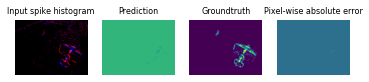

depth, batch 0


<Figure size 432x288 with 0 Axes>

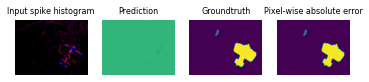

training:   1%|          | 1/116 [00:02<04:31,  2.36s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0538, -0.0455, -0.0426,  ...,  0.0309,  0.0391,  0.0445],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0571, -0.0484, -0.0453,  ...,  0.0328,  0.0415,  0.0473],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5., 6.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4866, 0.4886, 0.4893,  ..., 0.5077, 0.5098, 0.5111], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size

<Figure size 432x288 with 0 Axes>

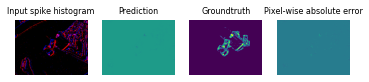

depth, batch 0


<Figure size 432x288 with 0 Axes>

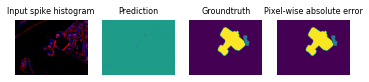

training:   2%|▏         | 2/116 [00:04<03:42,  1.95s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0470, -0.0457, -0.0454,  ...,  0.0317,  0.0319,  0.0371],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0500, -0.0485, -0.0482,  ...,  0.0337,  0.0339,  0.0394],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4882, 0.4886, 0.4887,  ..., 0.5079, 0.5080, 0.5093], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

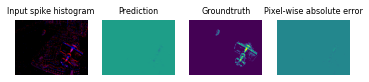

depth, batch 0


<Figure size 432x288 with 0 Axes>

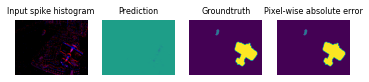

training:   3%|▎         | 3/116 [00:05<03:41,  1.96s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0952, -0.0894, -0.0798,  ...,  0.0560,  0.0584,  0.0666],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.1011, -0.0950, -0.0847,  ...,  0.0595,  0.0620,  0.0708],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4762, 0.4777, 0.4801,  ..., 0.5140, 0.5146, 0.5167], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

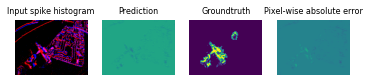

depth, batch 0


<Figure size 432x288 with 0 Axes>

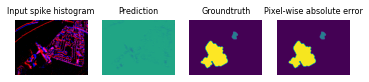

training:   3%|▎         | 4/116 [00:07<03:26,  1.85s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0773, -0.0658, -0.0622,  ...,  0.0392,  0.0502,  0.0531],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0821, -0.0699, -0.0661,  ...,  0.0417,  0.0533,  0.0564],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4807, 0.4836, 0.4844,  ..., 0.5098, 0.5125, 0.5133], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

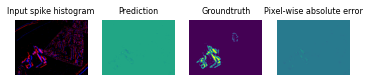

depth, batch 0


<Figure size 432x288 with 0 Axes>

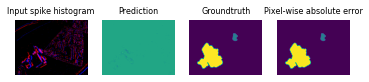

training:   4%|▍         | 5/116 [00:09<03:16,  1.77s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0818, -0.0817, -0.0678,  ...,  0.0523,  0.0526,  0.0589],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0869, -0.0868, -0.0721,  ...,  0.0555,  0.0558,  0.0625],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4796, 0.4796, 0.4831,  ..., 0.5131, 0.5131, 0.5147], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

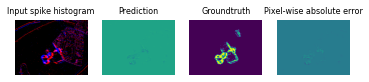

depth, batch 0


<Figure size 432x288 with 0 Axes>

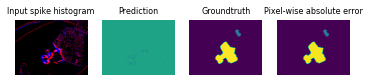

training:   5%|▌         | 6/116 [00:10<03:09,  1.72s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0583, -0.0579, -0.0563,  ...,  0.0467,  0.0473,  0.0526],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0619, -0.0616, -0.0599,  ...,  0.0496,  0.0502,  0.0559],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4854, 0.4855, 0.4859,  ..., 0.5117, 0.5118, 0.5131], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

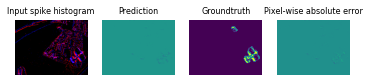

depth, batch 0


<Figure size 432x288 with 0 Axes>

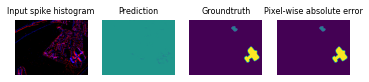

training:   6%|▌         | 7/116 [00:12<03:03,  1.68s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0477, -0.0434, -0.0420,  ...,  0.0376,  0.0391,  0.0422],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0507, -0.0461, -0.0447,  ...,  0.0399,  0.0415,  0.0448],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4881, 0.4892, 0.4895,  ..., 0.5094, 0.5098, 0.5105], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

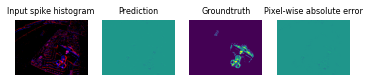

depth, batch 0


<Figure size 432x288 with 0 Axes>

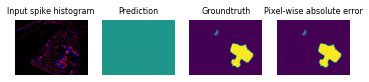

training:   7%|▋         | 8/116 [00:14<02:58,  1.66s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0422, -0.0419, -0.0409,  ...,  0.0425,  0.0457,  0.0459],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0449, -0.0445, -0.0434,  ...,  0.0452,  0.0485,  0.0487],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4894, 0.4895, 0.4898,  ..., 0.5106, 0.5114, 0.5115], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

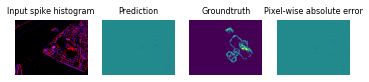

depth, batch 0


<Figure size 432x288 with 0 Axes>

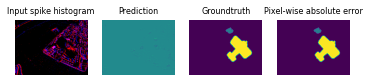

training:   8%|▊         | 9/116 [00:15<02:55,  1.64s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0658, -0.0646, -0.0629,  ...,  0.0650,  0.0679,  0.0859],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0700, -0.0686, -0.0669,  ...,  0.0690,  0.0721,  0.0913],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4835, 0.4839, 0.4843,  ..., 0.5162, 0.5170, 0.5215], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

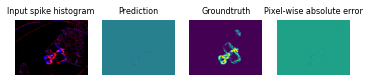

depth, batch 0


<Figure size 432x288 with 0 Axes>

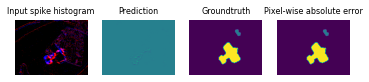

training:   9%|▊         | 10/116 [00:17<03:03,  1.73s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0551, -0.0478, -0.0439,  ...,  0.0539,  0.0542,  0.0592],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0585, -0.0508, -0.0467,  ...,  0.0573,  0.0576,  0.0629],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([ 0.,  1.,  2.,  3.,  4.,  5., 20.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4862, 0.4881, 0.4890,  ..., 0.5135, 0.5135, 0.5148], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  tor

<Figure size 432x288 with 0 Axes>

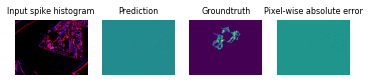

depth, batch 0


<Figure size 432x288 with 0 Axes>

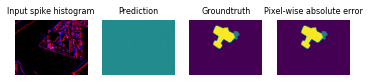

training:   9%|▉         | 11/116 [00:19<03:00,  1.72s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0478, -0.0396, -0.0389,  ...,  0.0419,  0.0495,  0.0526],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0508, -0.0421, -0.0414,  ...,  0.0445,  0.0526,  0.0559],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5., 6.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4881, 0.4901, 0.4903,  ..., 0.5105, 0.5124, 0.5131], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size

<Figure size 432x288 with 0 Axes>

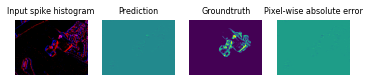

depth, batch 0


<Figure size 432x288 with 0 Axes>

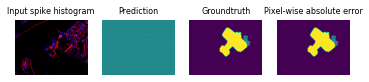

training:  10%|█         | 12/116 [00:20<02:55,  1.69s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0578, -0.0402, -0.0394,  ...,  0.0531,  0.0559,  0.0678],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0614, -0.0427, -0.0418,  ...,  0.0565,  0.0594,  0.0721],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4856, 0.4900, 0.4902,  ..., 0.5133, 0.5140, 0.5170], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

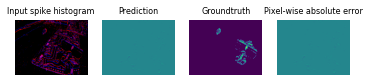

depth, batch 0


<Figure size 432x288 with 0 Axes>

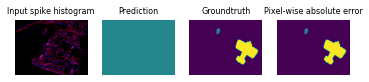

training:  11%|█         | 13/116 [00:22<02:52,  1.67s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0656, -0.0590, -0.0580,  ...,  0.0858,  0.0861,  0.1081],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0697, -0.0627, -0.0616,  ...,  0.0912,  0.0915,  0.1149],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4836, 0.4853, 0.4855,  ..., 0.5214, 0.5215, 0.5270], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

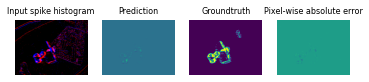

depth, batch 0


<Figure size 432x288 with 0 Axes>

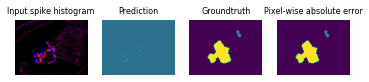

training:  12%|█▏        | 14/116 [00:24<02:48,  1.66s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0452, -0.0450, -0.0382,  ...,  0.0384,  0.0385,  0.0401],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0480, -0.0478, -0.0406,  ...,  0.0408,  0.0409,  0.0426],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4887, 0.4887, 0.4905,  ..., 0.5096, 0.5096, 0.5100], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

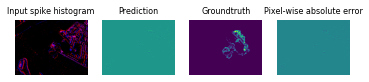

depth, batch 0


<Figure size 432x288 with 0 Axes>

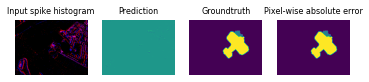

training:  13%|█▎        | 15/116 [00:25<02:45,  1.64s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0482, -0.0481, -0.0480,  ...,  0.0781,  0.0802,  0.0844],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0512, -0.0511, -0.0510,  ...,  0.0830,  0.0852,  0.0897],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([ 0.,  1.,  2.,  3.,  4.,  5., 20.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4880, 0.4880, 0.4880,  ..., 0.5195, 0.5200, 0.5211], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  tor

<Figure size 432x288 with 0 Axes>

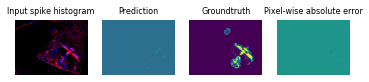

depth, batch 0


<Figure size 432x288 with 0 Axes>

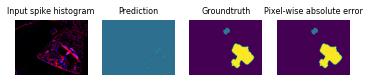

training:  14%|█▍        | 16/116 [00:27<02:44,  1.64s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0445, -0.0358, -0.0333,  ...,  0.0478,  0.0478,  0.0493],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0473, -0.0380, -0.0354,  ...,  0.0508,  0.0508,  0.0524],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4889, 0.4911, 0.4917,  ..., 0.5120, 0.5120, 0.5123], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

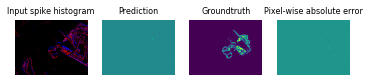

depth, batch 0


<Figure size 432x288 with 0 Axes>

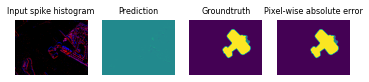

training:  15%|█▍        | 17/116 [00:29<02:48,  1.70s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0411, -0.0393, -0.0364,  ...,  0.0556,  0.0579,  0.0653],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0437, -0.0418, -0.0386,  ...,  0.0591,  0.0616,  0.0693],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5., 6.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4897, 0.4902, 0.4909,  ..., 0.5139, 0.5145, 0.5163], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size

<Figure size 432x288 with 0 Axes>

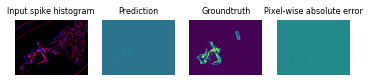

depth, batch 0


<Figure size 432x288 with 0 Axes>

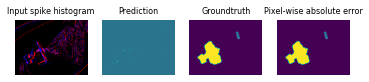

training:  16%|█▌        | 18/116 [00:31<02:47,  1.71s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0491, -0.0460, -0.0456,  ...,  0.0933,  0.1021,  0.1399],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0522, -0.0489, -0.0484,  ...,  0.0991,  0.1085,  0.1486],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4877, 0.4885, 0.4886,  ..., 0.5233, 0.5255, 0.5349], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

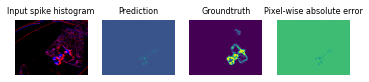

depth, batch 0


<Figure size 432x288 with 0 Axes>

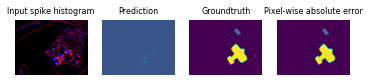

training:  16%|█▋        | 19/116 [00:32<02:45,  1.71s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0454, -0.0447, -0.0406,  ...,  0.0706,  0.0802,  0.0887],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0482, -0.0475, -0.0431,  ...,  0.0750,  0.0852,  0.0943],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4887, 0.4888, 0.4899,  ..., 0.5176, 0.5200, 0.5222], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

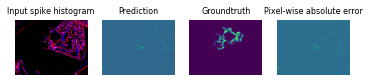

depth, batch 0


<Figure size 432x288 with 0 Axes>

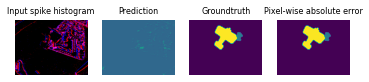

training:  17%|█▋        | 20/116 [00:34<02:41,  1.68s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0408, -0.0353, -0.0329,  ...,  0.0470,  0.0482,  0.0540],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0434, -0.0376, -0.0349,  ...,  0.0499,  0.0512,  0.0574],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4898, 0.4912, 0.4918,  ..., 0.5117, 0.5120, 0.5135], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

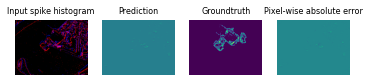

depth, batch 0


<Figure size 432x288 with 0 Axes>

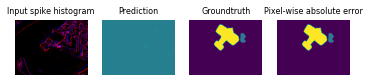

training:  18%|█▊        | 21/116 [00:36<02:38,  1.67s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0496, -0.0413, -0.0403,  ...,  0.0627,  0.0726,  0.0746],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0528, -0.0438, -0.0429,  ...,  0.0666,  0.0771,  0.0792],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4876, 0.4897, 0.4899,  ..., 0.5157, 0.5181, 0.5186], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

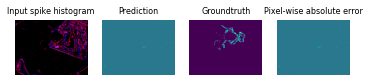

depth, batch 0


<Figure size 432x288 with 0 Axes>

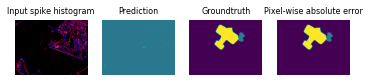

training:  19%|█▉        | 22/116 [00:37<02:35,  1.66s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0582, -0.0563, -0.0528,  ...,  0.1693,  0.1835,  0.1911],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0619, -0.0598, -0.0561,  ...,  0.1884,  0.2004,  0.2033],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4854, 0.4859, 0.4868,  ..., 0.5422, 0.5458, 0.5476], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

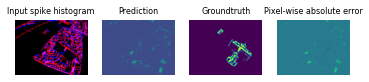

depth, batch 0


<Figure size 432x288 with 0 Axes>

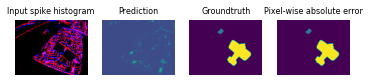

training:  20%|█▉        | 23/116 [00:39<02:32,  1.64s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0406, -0.0363, -0.0348,  ...,  0.0776,  0.0782,  0.0859],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0431, -0.0386, -0.0370,  ...,  0.0825,  0.0831,  0.0912],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4899, 0.4909, 0.4913,  ..., 0.5194, 0.5195, 0.5214], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

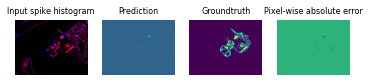

depth, batch 0


<Figure size 432x288 with 0 Axes>

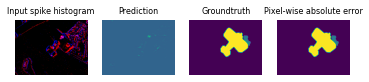

training:  21%|██        | 24/116 [00:41<02:37,  1.72s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0298, -0.0284, -0.0284,  ...,  0.0427,  0.0438,  0.0475],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0317, -0.0302, -0.0302,  ...,  0.0454,  0.0465,  0.0505],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4925, 0.4929, 0.4929,  ..., 0.5107, 0.5109, 0.5119], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

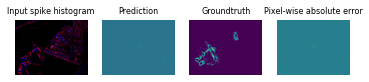

depth, batch 0


<Figure size 432x288 with 0 Axes>

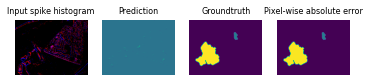

training:  22%|██▏       | 25/116 [00:42<02:33,  1.69s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0487, -0.0481, -0.0479,  ...,  0.0604,  0.0623,  0.0660],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0518, -0.0512, -0.0509,  ...,  0.0642,  0.0662,  0.0701],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4878, 0.4880, 0.4880,  ..., 0.5151, 0.5156, 0.5165], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

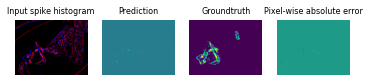

depth, batch 0


<Figure size 432x288 with 0 Axes>

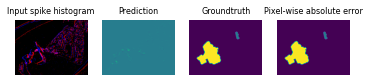

training:  22%|██▏       | 26/116 [00:44<02:33,  1.71s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0487, -0.0342, -0.0290,  ...,  0.0490,  0.0557,  0.0578],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0518, -0.0364, -0.0308,  ...,  0.0521,  0.0592,  0.0614],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4878, 0.4914, 0.4928,  ..., 0.5123, 0.5139, 0.5145], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

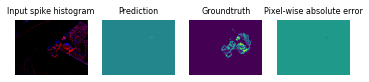

depth, batch 0


<Figure size 432x288 with 0 Axes>

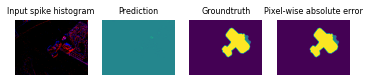

training:  23%|██▎       | 27/116 [00:46<02:30,  1.70s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0461, -0.0450, -0.0443,  ...,  0.1399,  0.1562,  0.1873],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0490, -0.0479, -0.0470,  ...,  0.1487,  0.1660,  0.1990],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4885, 0.4887, 0.4889,  ..., 0.5349, 0.5390, 0.5467], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

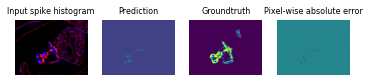

depth, batch 0


<Figure size 432x288 with 0 Axes>

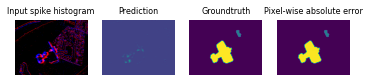

training:  24%|██▍       | 28/116 [00:47<02:28,  1.69s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0544, -0.0368, -0.0363,  ...,  0.0386,  0.0439,  0.0505],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0578, -0.0391, -0.0385,  ...,  0.0410,  0.0467,  0.0536],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4864, 0.4908, 0.4909,  ..., 0.5096, 0.5110, 0.5126], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

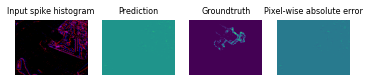

depth, batch 0


<Figure size 432x288 with 0 Axes>

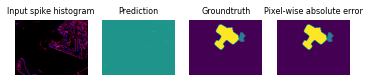

training:  25%|██▌       | 29/116 [00:49<02:25,  1.68s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0457, -0.0326, -0.0294,  ...,  0.0470,  0.0477,  0.0486],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0485, -0.0347, -0.0313,  ...,  0.0499,  0.0506,  0.0516],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4886, 0.4918, 0.4926,  ..., 0.5117, 0.5119, 0.5121], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

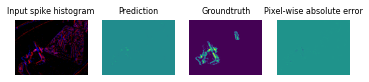

depth, batch 0


<Figure size 432x288 with 0 Axes>

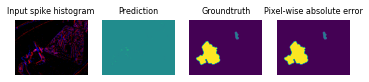

training:  26%|██▌       | 30/116 [00:51<02:23,  1.66s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0555, -0.0530, -0.0521,  ...,  0.0878,  0.0886,  0.1034],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0589, -0.0563, -0.0554,  ...,  0.0933,  0.0941,  0.1099],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([ 0.,  1.,  2.,  3.,  4.,  5., 20.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4861, 0.4868, 0.4870,  ..., 0.5219, 0.5221, 0.5258], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  tor

training:  26%|██▌       | 30/116 [00:51<02:28,  1.73s/it]


KeyboardInterrupt: ignored

<Figure size 432x288 with 0 Axes>

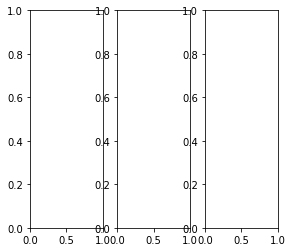

In [ ]:
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning

functional.reset_net(net)               

for epoch in range(n_epochs):
    
    show=True
    net = net.train()               #<--------   0
    running_train_loss = 0
    running_train_IOU = 0
    start_time = time.time()    
    with torch.autograd.set_detect_anomaly(True):
        for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
            if (data == None):
                continue
            functional.reset_net(net)                               #<--------  6                
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
            spikes_input = spikes_input.permute(0,1,4,2,3) 

            seg_masked = data['masked_spike_tensor']
            seg_masked = seg_masked.permute(0,1,4,2,3)     

            depth_masked = data['depth_mask_tensor']
            depth_masked = depth_masked.permute(0,1,4,2,3)     

            if not MultiStep:                                   #   sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                seg_masked = torch.sum(seg_masked,axis=0,keepdim=True)  
                depth_masked = torch.sum(depth_masked,axis=0,keepdim=True)  

            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            seg_masked = seg_masked.to(device)
            depth_masked = depth_masked.to(device)

            seg_pred_list,depth_pred_list =  net(spikes_input)                #<--------   2  # len(spike_pred_list) = 4
            # seg_pred_list = net(spikes_input) 
            seg_pred =  seg_pred_list[3].to(device)
            seg_pred = torch.sigmoid(seg_pred)
            depth_pred =  depth_pred_list[3].to(device)

            if seg_pred.ndim == 4:
                # spike_input_crop = spikes_input[:, :, :, :seg_pred.size(2), :seg_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                seg_masked_crop = seg_masked[:, :, :, :seg_pred.size(2), :seg_pred.size(3)]       #ndim 4  (B,1,1,260,346)
                depth_masked_crop = depth_masked[:, :, :, :depth_pred.size(2), :depth_pred.size(3)]
                seg_pred_4D = torch.sum(seg_pred, axis = (1),keepdim=True) #
                depth_pred_4D = torch.sum(depth_pred, axis = (1),keepdim=True) #                

                # spike_input_crop = spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]
                # seg_input_crop = seg_input[:, :, :, :seg_pred.size(2), :seg_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                # seg_masked_crop = seg_masked[:, :, :, :seg_pred.size(2), :seg_pred.size(3)]       #ndim 4  (B,1,1,260,346)
                # seg_pred_4D = torch.sum(seg_pred, axis = (1),keepdim=True) #

                # depth_input_crop = depth_input[:, :, :, :depth_pred.size(2), :depth_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                # depth_masked_crop = depth_masked[:, :, :, :depth_pred.size(2), :depth_pred.size(3)]       #ndim 4  (B,1,1,260,346)
                # depth_pred_4D = torch.sum(depth_pred, axis = (1),keepdim=True) #
                
            elif seg_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (2))               #torch.Size([B, 1, 260, 346]) 
                spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop =spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
            
            seg_mask_4D = torch.any(seg_masked_crop, dim = 2,keepdim=False) #or and remove of TS dim 
            seg_mask_4D = torch.any(seg_mask_4D, dim = 1,keepdim=True)      #or of C dim
            seg_mask_4D = torch.mul(seg_mask_4D,1.)          #conversion to 

            depth_mask_4D = torch.mean(depth_masked_crop, dim = 2,keepdim=False) #or and remove of TS dim 
            depth_mask_4D = torch.mean(depth_mask_4D, dim = 1,keepdim=True)      #or of C dim
            #depth_mask_4D = torch.mul(depth_mask_4D,1.)          #conversion to 

            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])   
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])  
            # spike_mask_4D = torch.gt(spike_mask_4D, 1)

            if show:
                    #condition to colapse all timesteps in every batch
                spikes_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) 
                spikes_input_5D = spikes_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)

                print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())

                print("seg_pred numbers from net: ",torch.unique(seg_pred_list[3])," of size: ",seg_pred_list[3].size())
                print("depth_pred numbers from net: ",torch.unique(depth_pred_list[3])," of size: ",depth_pred_list[3].size())

                print("seg_mask numbers from db: ",torch.unique(seg_masked)," of size: ",seg_masked.size())
                print("depth_mask numbers from db: ",torch.unique(depth_masked)," of size: ",depth_masked.size())


                print("spike_input 5d numbers to viz: ",torch.unique(spikes_input_5D)," of size: ",spikes_input_5D.size())  

                print("seg_pred numbers to loss/viz: ",torch.unique(seg_pred_4D)," of size: ",seg_pred_4D.size())                
                print("seg_mask numbers to loss/viz: ",torch.unique(seg_mask_4D)," of size: ",seg_mask_4D.size())

                print("depth_pred numbers to loss/viz: ",torch.unique(depth_pred_4D)," of size: ",depth_pred_4D.size())                
                print("depth_mask numbers to loss/viz: ",torch.unique(depth_mask_4D)," of size: ",depth_mask_4D.size())
                for e in range(spikes_input_5D.size(0)):
                    show_learning(fig,False, 
                                  spikes_input_5D[None,e,:,:,:,:], 
                                  seg_pred_4D[None,e,:,:,:], 
                                  seg_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                for e in range(spikes_input_5D.size(0)):
                    show_learning(fig,False, 
                                  spikes_input_5D[None,e,:,:,:,:], 
                                  depth_pred_4D[None,e,:,:,:], 
                                  depth_mask_4D[None,e,:,:,:], 'depth, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i                  
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)    

            # loss = loss_module(seg_pred_4D, seg_mask_4D,depth_pred_4D, depth_mask_4D)        #<--------  3
            loss = loss_module(seg_pred_4D, seg_mask_4D)
            loss.backward()                                         #<--------  4
            optimizer.step()                                        #<--------  5

            optimizer.zero_grad()                               #<--------   1 
            running_train_loss += loss.item() / spikes_input.size(0)
            seg_pred = torch.round(seg_pred)
            running_train_IOU += getIOU(seg_pred,seg_mask_4D)

                # process saved metrics
        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_IOU = running_train_IOU / len(train_loader)
        train_loss_vec.append(float(epoch_train_loss))
        train_error_vec.append(float(epoch_train_IOU))
        epoch_train_time = time.time() - start_time
        train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)

        # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
        # tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
        #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
#################
    running_test_loss = 0
    running_test_IOU = 0
    net.eval()
    show=True
    
    with torch.no_grad():
        start_time = time.time()
        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            functional.reset_net(net)     
            optimizer.zero_grad()        
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)                           
            if not MultiStep:   #sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()
            
            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            spike_pred =  spike_pred_list[3].to(device)             # (1,1,260,346)
            spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                #spike_pred_4D = spike_pred
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346]) 
                spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS 
            spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to         
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])   
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])   

            if show:
                #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print("spike_pred numbers from net: ",torch.unique(spike_pred_list[3])," of size: ",spike_pred_list[3].size())
                print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())                
                print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())                
                print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_input_5D.size(0)):
                    show_learning(fig,False, 
                                    spike_input_5D[None,e,:,:,:,:], 
                                    spike_pred_4D[None,e,:,:,:], 
                                    spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)  
            
            loss = loss_module(spike_pred_4D, spike_mask_4D)      
                
            running_test_loss += loss / spikes_input.size(0)
            spike_pred = torch.round(spike_pred)
            running_test_IOU += getIOU(spike_pred, spike_mask_4D)

                # process saved metrics
        epoch_test_loss = running_test_loss / len(test_loader)        
        epoch_test_IOU = running_test_IOU / len(test_loader)
        test_loss_vec.append(float(epoch_test_loss))
        test_error_vec.append(float(epoch_test_IOU))
        epoch_test_time = time.time() - start_time
        test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
        print(train_epoch_summary + test_epoch_summary)
        logfile.write(train_epoch_summary + test_epoch_summary)

        # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
        # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)

        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': epoch_test_loss, 'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec
                        }, "./results/checkpoints/stereospike_seg_sergio3.pth")
            
        net.increment_epoch()
        scheduler.step()
        # Training/testing plots
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.title("Loss")
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.title("IoU (%)")
        plt.show()
print("training finished !")

In [ ]:
print(net.epoch)
print(net.get_max_accuracy())
print(epoch_test_loss)

In [ ]:
x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.title("Loss")
plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.title("IoU")
plt.show()

# test

In [ ]:
from torch._C import dtype
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=True
from viz import show_learning
show = True           # display network's predictions during training / validation

############
# Test #
############
running_test_loss = 0
running_test_IOU = 0
net.eval()
show=True

with torch.no_grad():
    start_time = time.time()
    for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
        if (data == None):
            continue
        functional.reset_net(net)     
        optimizer.zero_grad()        
        spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
        spikes_masked = data['masked_spike_tensor']
        spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
        spikes_masked = spikes_masked.permute(0,1,4,2,3)                           
        if not MultiStep:   #sums all time steps in the dim=0
            spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
        spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
        spikes_masked = spikes_masked.to(device)
        spikes_input.requires_grad_()
        
        spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
        #spike_pred_list = functional.multi_step_forward(spikes_input, net)
        spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)
        spike_pred = torch.sigmoid(spike_pred)
        # print("output net: ",spike_pred_list[3].size())
        print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
        if spike_pred.ndim == 4:
            spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
            spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
            #spike_pred_4D = spike_pred
            spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

        elif spike_pred.ndim == 5:
            spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346]) 
            spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
            spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

        spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])   
        spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])   

        if show:
            if MultiStep:       #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
            for e in range(spike_input_5D.size(0)):
                show_learning(fig,False, 
                                spike_input_5D[None,e,:,:,:,:], 
                                spike_pred_4D[None,e,:,:,:], 
                                spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
            #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)    
        loss = loss_module(spike_pred_4D, spike_mask_4D)      
            
        running_test_loss += loss / spikes_input.size(0)
        running_test_IOU += getIOU(spike_pred, spike_mask_4D)

            # process saved metrics
    epoch_test_loss = running_test_loss / len(test_loader)        
    epoch_test_IOU = running_test_IOU / len(test_loader)
    test_loss_vec.append(float(epoch_test_loss))
    test_error_vec.append(float(epoch_test_IOU))
    epoch_test_time = time.time() - start_time
    test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
    print( test_epoch_summary)

    tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
    tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)


    scheduler.step()

    x=[x for x in range(len(train_loss_vec))]
    y=[y for y in range(len(test_loss_vec))]
    plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
    plt.title("Loss")
    plt.show()

    x=[x for x in range(len(train_error_vec))]
    y=[y for y in range(len(test_error_vec))]
    plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
    plt.title("IoU")
    plt.show()
print("training finished !")


In [ ]:
%cd /content/drive/MyDrive/StereoSpikeA/OF_EV_SNN
!ls
!python /content/drive/MyDrive/StereoSpikeA/OF_EV_SNN/network_3d/poolingNet_cat_1res.py

# otros

In [ ]:
dir=str('/content/drive/MyDrive/StereoSpike/results/visualizations2/')
make_vid_from_pngs(dir, (2160,1440), 20, 'results/preds3.mp4') #1700,403

In [ ]:
!python train_evimo.py

In [ ]:
!python /content/drive/MyDrive/StereoSpike/datasets/MVSEC/utils.py

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from datasets.MVSEC.utils import mvsecToVideo, mvsecSpikesAndDepth, mvsecShowBlended, mvsecLoadRectificationMaps, mvsecRectifyEvents, mvsecCumulateSpikesIntoFrames, mvsecSpikesAndDepth
# load dataset files
root = '/content/drive/MyDrive/StereoSpike/datasets/MVSEC/data/'
datafile = root + 'indoor_flying/indoor_flying4_data'
data = h5py.File(datafile + '.hdf5', 'r')
datafile_gt = root + 'indoor_flying/indoor_flying4_gt'
data_gt = h5py.File(datafile_gt + '.hdf5', 'r')

# raw grayscale images
images = data['davis']['left']['image_raw']
#mvsecToVideo(images)

# depth maps
Ldepths_rect = data_gt['davis']['left']['depth_image_rect']  # RECTIFIED / LEFT
Rdepths_rect = data_gt['davis']['right']['depth_image_rect']  # RECTIFIED / RIGHT
Ldepths_raw = data_gt['davis']['left']['depth_image_raw']  # RAW / LEFT
Rdepths_raw = data_gt['davis']['right']['depth_image_raw']  # RAW / RIGHT
Ldepths_rect_ts = np.array(data_gt['davis']['left']['depth_image_rect_ts'])
Rdepths_rect_ts = np.array(data_gt['davis']['right']['depth_image_rect_ts'])

# blended: Visualization of all events from the left DAVIS that are 25ms from each left depth map superimposed on
# the depth map. Gives a preview of what each sequence looks like. Provided by the authors of the dataset.
Lblended = data_gt['davis']['left']['blended_image_rect']
Rblended = data_gt['davis']['right']['blended_image_rect']

# get the events
Levents = np.array(data['davis']['left']['events'])  # EVENTS: X Y TIME POLARITY
Revents = np.array(data['davis']['right']['events'])  # EVENTS: X Y TIME POLARITY

# rectify the coordinates of spike events
Lx_path = root + 'indoor_flying/indoor_flying_calib/indoor_flying_left_x_map.txt'
Ly_path = root + 'indoor_flying/indoor_flying_calib/indoor_flying_left_y_map.txt'
Rx_path = root + 'indoor_flying/indoor_flying_calib/indoor_flying_right_x_map.txt'
Ry_path = root + 'indoor_flying/indoor_flying_calib/indoor_flying_right_y_map.txt'
Lx_map, Ly_map, Rx_map, Ry_map = mvsecLoadRectificationMaps(Lx_path, Ly_path, Rx_path, Ry_path)
rect_Levents = mvsecRectifyEvents(Levents, Lx_map, Ly_map)
rect_Revents = mvsecRectifyEvents(Revents, Rx_map, Ry_map)

# show data in a video file (cumulated spikes between frames)
#mvsecToVideo(images)
AER_frames, sync_labels = mvsecCumulateSpikesIntoFrames(rect_Levents, Ldepths_rect, Ldepths_rect_ts, 2)
mvsecSpikesAndDepth(Ldepths_rect, rect_Levents, Lblended)
mvsecShowBlended(Lblended, Rblended)
mvsecShowDepth(Ldepths_rect, Rdepths_rect, Ldepths_raw, Rdepths_raw, Rblended, Lblended)


In [ ]:
#!pip install spikingjelly==0.0.0.0.12
%cd /content/drive/MyDrive
!git clone https://github.com/fangwei123456/spikingjelly.git
%cd /content/drive/MyDrive/spikingjelly
!git checkout 0.0.0.0.12
!python setup.py install
#!ls


In [ ]:
import torch
from spikingjelly.activation_based import neuron
from spikingjelly import visualizing
from matplotlib import pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 200
if_node = neuron.IFNode(v_reset=None)
T = 128
x = torch.arange(-0.2, 1.2, 0.04)
plt.scatter(torch.arange(x.shape[0]), x)
plt.title('Input $x_{i}$ to IF neurons')
plt.xlabel('Neuron index $i$')
plt.ylabel('Input $x_{i}$')
plt.grid(linestyle='-.')
plt.show()

#download & preprocess datasets




In [ ]:
# %cd /content/drive/MyDrive/datasets/EVIMO_Dataset/

# download database
# !wget https://obj.umiacs.umd.edu/evimo1npz/train_table_npz.tar.gz
# !wget https://obj.umiacs.umd.edu/evimo1txt/train_table_txt.tar.gz

# extract database
# !tar -xvf /content/drive/MyDrive/datasets/EVIMO_Dataset/eval_table_npz.tar.gz
# !tar -xvf /content/drive/MyDrive/datasets/EVIMO_Dataset/train_table_npz.tar.gz

!tar -xvf /content/drive/MyDrive/datasets/EVIMO_Dataset/train_table_txt.tar.gz
%cd /content/drive/MyDrive/StereoSpikeA



In [ ]:
# !python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000  -f /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00

!python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000  -f /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03

!python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000  -f /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01
!python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000  -f /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02
!python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000  -f /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03
!python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000  -f /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04
!python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000  -f /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05

Starting folder /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03
Traceback (most recent call last):
  File "/content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py", line 46, in <module>
    data = np.loadtxt(os.path.join(folder,"events.txt"))
  File "/usr/local/lib/python3.9/dist-packages/numpy/lib/npyio.py", line 1159, in loadtxt
    raise ValueError(
ValueError: Wrong number of columns at line 30771208
Starting folder /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01
  0% 167346/212081003 [00:00<02:06, 1673345.90it/s]update frame 1 0.160452
update frame 2 0.190491
  0% 334681/212081003 [00:01<14:40, 240500.69it/s] update frame 3 0.220472
  0% 412429/212081003 [00:01<18:03, 195384.04it/s]update frame 4 0.245466
  0% 460702/212081003 [00:02<22:57, 153621.10it/s]update frame 5 0.270495
  0% 498698/212081003 [00:02<27:39, 127473.38it/s]update frame 6 0.300447
  0% 566357/212081003 [00:03<28:23, 124154.80it/s]up

In [ ]:
from numpy import load

data = load('eval/table/npz/seq_02.npz')
lst = data.files
for item in lst:
    print(item)
    print(data[item].shape)
    # print(data[item])

events
(3230803, 4)
index
(401,)
discretization
()
K
(3, 3)
D
(4,)
depth
(129, 260, 346)
mask
(129, 260, 346)
meta


ValueError: ignored